In [3]:
# ============================================================================
# SIMPLE MONTHLY FORECASTING - XGBOOST ONLY (NO PROPHET ISSUES!)
# ============================================================================

# Step 1: Install Required Libraries
# ============================================================================
!pip install xgboost lightgbm scikit-learn -q

# Step 2: Import Libraries
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

# ============================================================================
# Step 3: Load Prepared Data
# ============================================================================
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load hourly data
df_hourly = pd.read_parquet('/content/drive/MyDrive/Junction2025/Data Preparation/fortum_prepared_full.parquet')
print(f"✅ Hourly data loaded: {df_hourly.shape}")

# Load groups metadata
groups_df = pd.read_csv('/content/drive/MyDrive/Junction2025/Data Preparation/groups_metadata.csv')
print(f"✅ Groups metadata loaded: {groups_df.shape}")

# ============================================================================
# Step 4: Aggregate Hourly Data to Monthly
# ============================================================================
print("\n" + "="*80)
print("AGGREGATING DATA TO MONTHLY LEVEL")
print("="*80)

# Create year-month column
df_hourly['year_month'] = df_hourly['measured_at'].dt.to_period('M')

# Aggregate consumption to monthly totals
monthly_agg = df_hourly.groupby(['group_id', 'year_month']).agg({
    'consumption': 'sum',  # Total monthly consumption
    'eur_per_mwh': 'mean',  # Average monthly price
    'temperature': 'mean' if 'temperature' in df_hourly.columns else lambda x: None,
    'humidity': 'mean' if 'humidity' in df_hourly.columns else lambda x: None,
    'is_weekend': 'mean',  # Proportion of weekend hours
    'is_holiday': 'mean',  # Proportion of holiday hours
    'daylight_hours': 'mean' if 'daylight_hours' in df_hourly.columns else lambda x: None,
}).reset_index()

# Convert period to timestamp (first day of month)
monthly_agg['ds'] = monthly_agg['year_month'].dt.to_timestamp()
monthly_agg = monthly_agg.drop('year_month', axis=1)

# Merge with group metadata
monthly_data = monthly_agg.merge(
    groups_df[['group_id', 'macro_region', 'segment', 'product_type', 'consumption_bucket']],
    on='group_id',
    how='left'
)

# Sort by group and date
monthly_data = monthly_data.sort_values(['group_id', 'ds']).reset_index(drop=True)

print(f"✅ Monthly data created: {monthly_data.shape}")
print(f"   - Date range: {monthly_data['ds'].min()} to {monthly_data['ds'].max()}")
print(f"   - Months per group: {len(monthly_data) / monthly_data['group_id'].nunique():.1f}")

# Display sample
print("\n📋 Sample monthly data:")
print(monthly_data.head())

# ============================================================================
# Step 5: Create Monthly Features
# ============================================================================
print("\n" + "="*80)
print("CREATING MONTHLY FEATURES")
print("="*80)

# Extract time features
monthly_data['month'] = monthly_data['ds'].dt.month
monthly_data['year'] = monthly_data['ds'].dt.year
monthly_data['quarter'] = monthly_data['ds'].dt.quarter

# Season
monthly_data['season'] = monthly_data['month'].apply(lambda x:
    0 if x in [12, 1, 2] else  # Winter
    1 if x in [3, 4, 5] else    # Spring
    2 if x in [6, 7, 8] else    # Summer
    3                           # Fall
)

# Cyclical encoding for month
monthly_data['month_sin'] = np.sin(2 * np.pi * monthly_data['month'] / 12)
monthly_data['month_cos'] = np.cos(2 * np.pi * monthly_data['month'] / 12)

# Create lag features
print("⏳ Creating lag features...")
monthly_data['lag_1m'] = monthly_data.groupby('group_id')['consumption'].shift(1)
monthly_data['lag_2m'] = monthly_data.groupby('group_id')['consumption'].shift(2)
monthly_data['lag_3m'] = monthly_data.groupby('group_id')['consumption'].shift(3)
monthly_data['lag_6m'] = monthly_data.groupby('group_id')['consumption'].shift(6)
monthly_data['lag_12m'] = monthly_data.groupby('group_id')['consumption'].shift(12)

# Rolling features
print("⏳ Creating rolling features...")
monthly_data['rolling_3m'] = monthly_data.groupby('group_id')['consumption'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)
monthly_data['rolling_6m'] = monthly_data.groupby('group_id')['consumption'].transform(
    lambda x: x.shift(1).rolling(window=6, min_periods=1).mean()
)
monthly_data['rolling_12m'] = monthly_data.groupby('group_id')['consumption'].transform(
    lambda x: x.shift(1).rolling(window=12, min_periods=1).mean()
)

# Standard deviation features
monthly_data['rolling_std_3m'] = monthly_data.groupby('group_id')['consumption'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).std()
)
monthly_data['rolling_std_12m'] = monthly_data.groupby('group_id')['consumption'].transform(
    lambda x: x.shift(1).rolling(window=12, min_periods=1).std()
)

# Year-over-year growth
monthly_data['yoy_growth'] = (
    (monthly_data['consumption'] - monthly_data['lag_12m']) /
    (monthly_data['lag_12m'] + 1e-10)
)

# Month-over-month growth
monthly_data['mom_growth'] = (
    (monthly_data['consumption'] - monthly_data['lag_1m']) /
    (monthly_data['lag_1m'] + 1e-10)
)

# Trend features
monthly_data['time_idx'] = monthly_data.groupby('group_id').cumcount()

print("✅ All features created")

# ============================================================================
# Step 6: Encode Categorical Variables
# ============================================================================
print("\n" + "="*80)
print("ENCODING CATEGORICAL VARIABLES")
print("="*80)

le_region = LabelEncoder()
le_segment = LabelEncoder()
le_product = LabelEncoder()
le_bucket = LabelEncoder()

monthly_data['region_encoded'] = le_region.fit_transform(monthly_data['macro_region'].astype(str))
monthly_data['segment_encoded'] = le_segment.fit_transform(monthly_data['segment'].astype(str))
monthly_data['product_encoded'] = le_product.fit_transform(monthly_data['product_type'].astype(str))
monthly_data['bucket_encoded'] = le_bucket.fit_transform(monthly_data['consumption_bucket'].astype(str))

print("✅ Categorical variables encoded")

# ============================================================================
# Step 7: Define Feature Sets
# ============================================================================
print("\n" + "="*80)
print("DEFINING FEATURE SETS")
print("="*80)

# Base features
base_features = [
    'month', 'quarter', 'season', 'time_idx',
    'month_sin', 'month_cos',
    'region_encoded', 'segment_encoded', 'product_encoded', 'bucket_encoded',
]

# Lag features
lag_features = [
    'lag_1m', 'lag_2m', 'lag_3m', 'lag_6m', 'lag_12m'
]

# Rolling features
rolling_features = [
    'rolling_3m', 'rolling_6m', 'rolling_12m',
    'rolling_std_3m', 'rolling_std_12m'
]

# Growth features
growth_features = [
    'yoy_growth', 'mom_growth'
]

# External features
external_features = ['eur_per_mwh']
if 'temperature' in monthly_data.columns:
    external_features.append('temperature')
if 'humidity' in monthly_data.columns:
    external_features.append('humidity')
if 'is_weekend' in monthly_data.columns:
    external_features.append('is_weekend')
if 'is_holiday' in monthly_data.columns:
    external_features.append('is_holiday')
if 'daylight_hours' in monthly_data.columns:
    external_features.append('daylight_hours')

# Combine all features
all_features = base_features + lag_features + rolling_features + growth_features + external_features

print(f"✅ Total features: {len(all_features)}")
print(f"   - Base: {len(base_features)}")
print(f"   - Lag: {len(lag_features)}")
print(f"   - Rolling: {len(rolling_features)}")
print(f"   - Growth: {len(growth_features)}")
print(f"   - External: {len(external_features)}")

# ============================================================================
# Step 8: Train/Validation Split
# ============================================================================
print("\n" + "="*80)
print("CREATING TRAIN/VALIDATION SPLIT")
print("="*80)

# Split date
split_date = pd.Timestamp('2023-10-01')

# Create splits
train_data = monthly_data[monthly_data['ds'] < split_date].copy()
val_data = monthly_data[monthly_data['ds'] >= split_date].copy()

# Remove rows with missing values in features
train_data_clean = train_data.dropna(subset=all_features + ['consumption'])
val_data_clean = val_data.dropna(subset=all_features + ['consumption'])

print(f"✅ Train set: {len(train_data_clean)} months")
print(f"   Date range: {train_data_clean['ds'].min()} to {train_data_clean['ds'].max()}")
print(f"✅ Validation set: {len(val_data_clean)} months")
print(f"   Date range: {val_data_clean['ds'].min()} to {val_data_clean['ds'].max()}")

# Prepare X and y
X_train = train_data_clean[all_features]
y_train = train_data_clean['consumption']

X_val = val_data_clean[all_features]
y_val = val_data_clean['consumption']

print(f"\n📊 Final shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val: {X_val.shape}")

# ============================================================================
# Step 9: Train XGBoost Model
# ============================================================================
print("\n" + "="*80)
print("TRAINING XGBOOST MODEL")
print("="*80)

print("⏳ Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1,
    early_stopping_rounds=50,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"✅ XGBoost trained!")
print(f"   Best iteration: {xgb_model.best_iteration}")

# ============================================================================
# Step 10: Train LightGBM Model (for ensemble)
# ============================================================================
print("\n" + "="*80)
print("TRAINING LIGHTGBM MODEL")
print("="*80)

print("⏳ Training LightGBM...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    objective='regression',
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

print(f"✅ LightGBM trained!")

✅ Libraries imported successfully!

LOADING DATA
✅ Hourly data loaded: (3679872, 60)
✅ Groups metadata loaded: (112, 8)

AGGREGATING DATA TO MONTHLY LEVEL
✅ Monthly data created: (5040, 13)
   - Date range: 2021-01-01 00:00:00 to 2024-09-01 00:00:00
   - Months per group: 45.0

📋 Sample monthly data:
   group_id  consumption  eur_per_mwh  temperature   humidity  is_weekend  \
0        28  6954.582492    51.246411    -2.726075  89.323925    0.322581   
1        28  7108.646496    57.095982    -5.569048  86.254464    0.285714   
2        28  5924.561988    38.319019    -0.634005  83.819892    0.258065   
3        28  4160.190185    36.833500     3.294028  79.268056    0.266667   
4        28  3128.195548    44.198964     7.711828  81.331989    0.322581   

   is_holiday  daylight_hours         ds     macro_region  segment  \
0    0.064516        6.815484 2021-01-01  Eastern Finland  Private   
1    0.000000        9.158214 2021-02-01  Eastern Finland  Private   
2    0.000000       11.84


MAKING VALIDATION PREDICTIONS
✅ Predictions complete

CALCULATING METRICS

📊 XGBoost Metrics:
   - MAE:  75.15
   - RMSE: 251.56
   - MAPE: 4.41%

📊 LightGBM Metrics:
   - MAE:  79.74
   - RMSE: 270.26
   - MAPE: 4.80%

📊 Ensemble Metrics:
   - MAE:  76.35
   - RMSE: 258.24
   - MAPE: 4.48%

CALCULATING BASELINE AND FVA

📊 Baseline (Same Month Last Year) Metrics:
   - MAE:  117.32
   - RMSE: 312.21
   - MAPE: 10.21%

🎯 Forecast Value Added (FVA):
   - XGBoost FVA:  56.80%
   - LightGBM FVA: 52.93%
   - Ensemble FVA: 56.08%

   ✅ Ensemble is 56.08% better than baseline!

FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Important Features:
        feature  importance
        lag_12m    0.744336
         lag_1m    0.182323
      month_cos    0.027083
    temperature    0.012048
       humidity    0.008809
 daylight_hours    0.004919
    rolling_12m    0.004243
     mom_growth    0.003122
     yoy_growth    0.002916
       time_idx    0.002057
 rolling_std_3m    0.001856
          month    0.000855


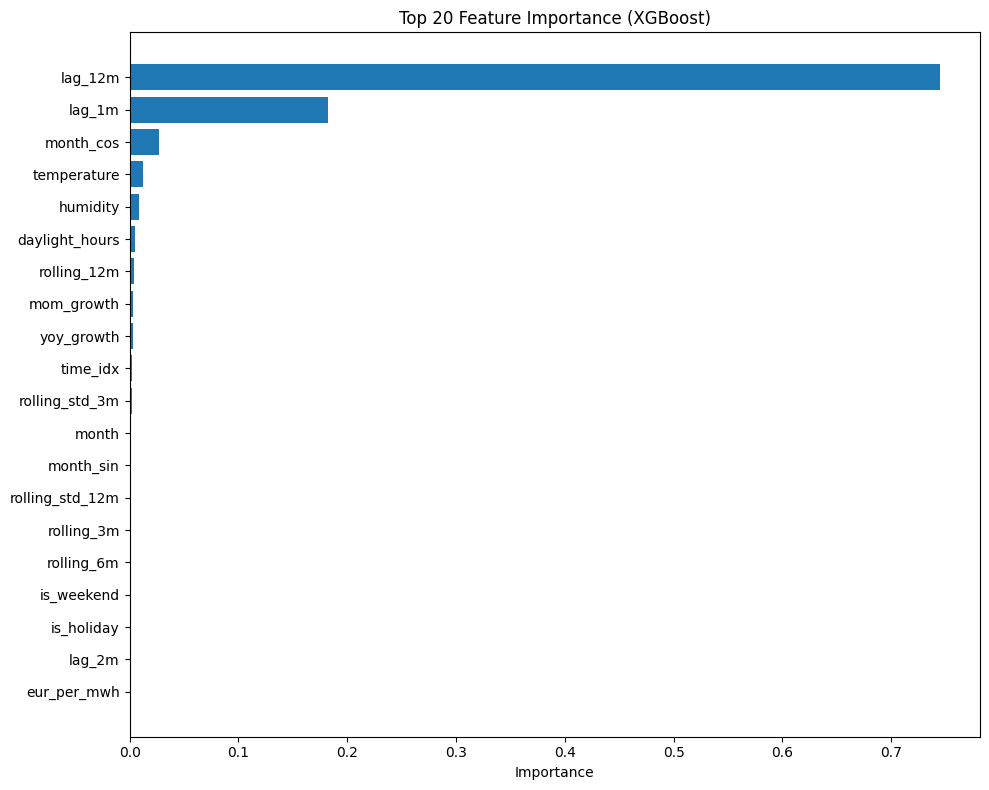


VISUALIZING PREDICTIONS
✅ Saved: monthly_predictions_validation.png


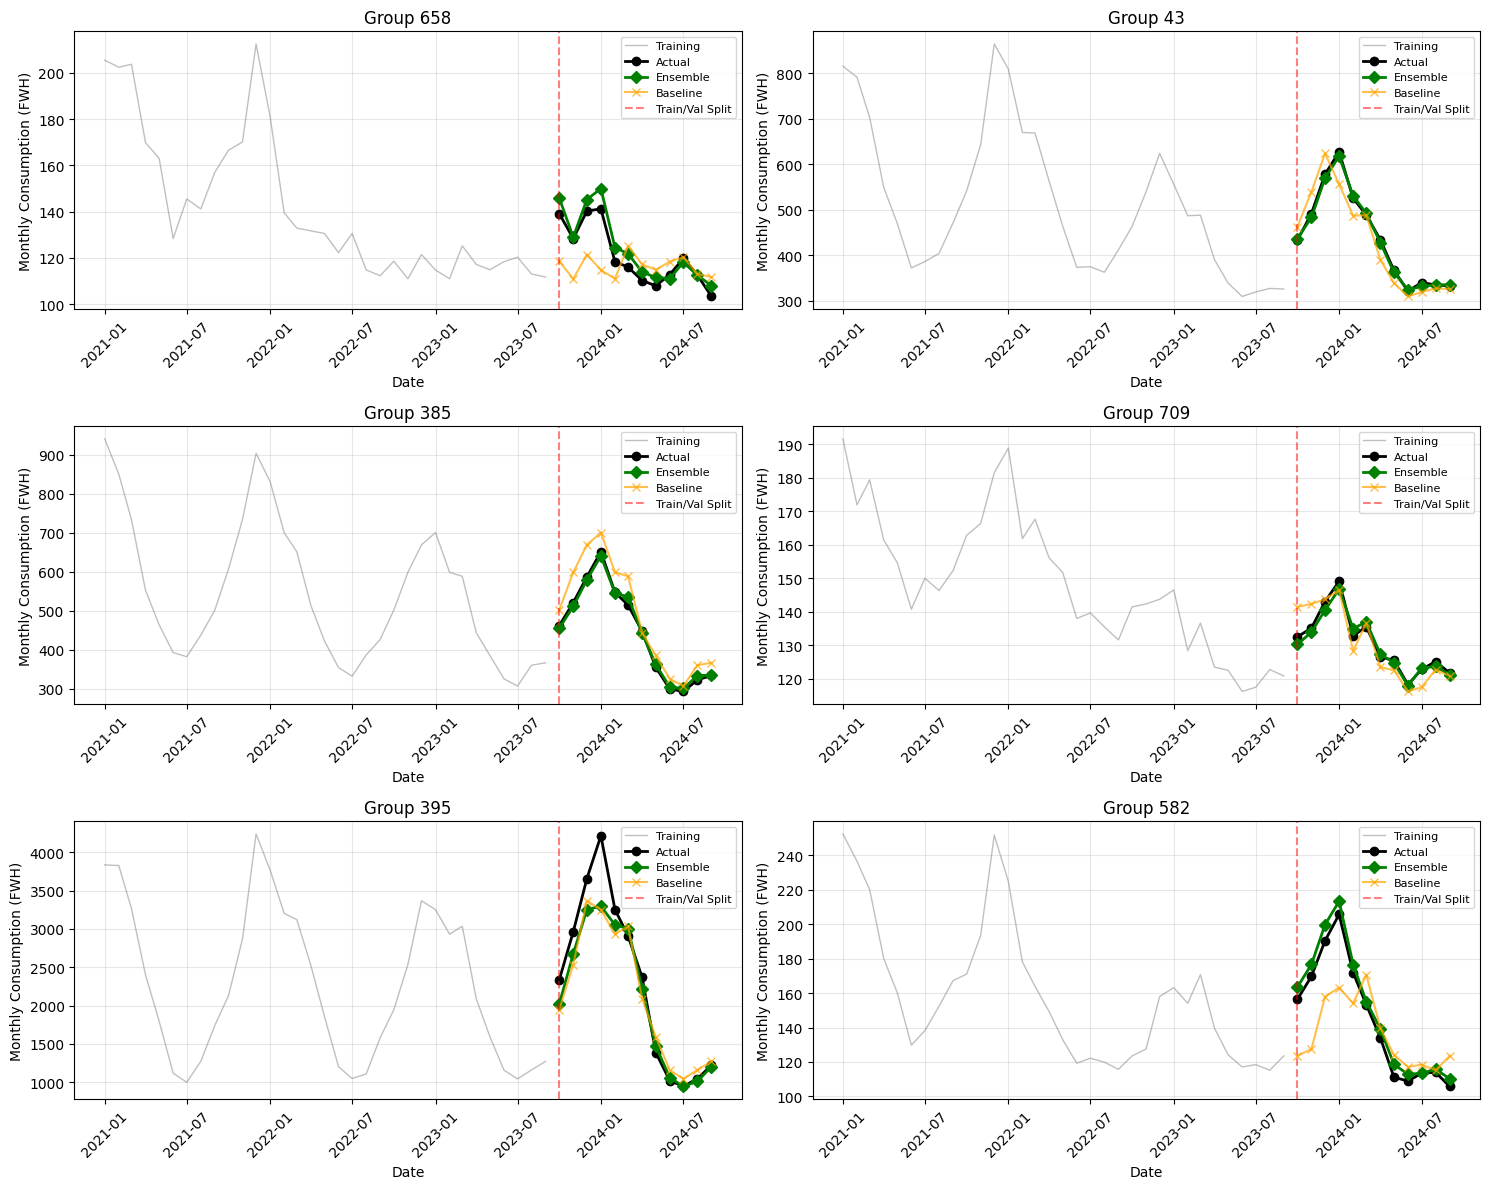


PREPARING TEST DATA (OCT 2024 - SEP 2025)
✅ Predicting 12 months

⏳ Making predictions for each group...
   Progress: 20/112 groups
   Progress: 40/112 groups
   Progress: 60/112 groups
   Progress: 80/112 groups
   Progress: 100/112 groups

✅ Test predictions complete: 1344 predictions

FORMATTING FOR SUBMISSION
✅ Submission shape: (12, 113)

📋 Preview:
group_id measured_at           28          29           30          36  \
0         2024-10-01  3207.039570  119.088911   587.888420  290.561039   
1         2024-11-01  5070.436001  134.213531   857.714721  426.133313   
2         2024-12-01  5787.748294  151.969122  1050.555750  456.562733   
3         2025-01-01  6334.253016  155.129804  1130.401184  546.272811   
4         2025-02-01  5764.406722  134.316517   964.122931  459.171810   

group_id          37          38          39          40          41  ...  \
0         138.096756  465.053430  138.998724  133.214683  490.636703  ...   
1         156.212233  640.396365  156.06788

In [4]:


# ============================================================================
# Step 11: Make Predictions
# ============================================================================
print("\n" + "="*80)
print("MAKING VALIDATION PREDICTIONS")
print("="*80)

# XGBoost predictions
xgb_pred = xgb_model.predict(X_val)

# LightGBM predictions
lgb_pred = lgb_model.predict(X_val)

# Ensemble (average)
ensemble_pred = 0.5 * xgb_pred + 0.5 * lgb_pred

print("✅ Predictions complete")

# ============================================================================
# Step 12: Calculate Metrics
# ============================================================================
print("\n" + "="*80)
print("CALCULATING METRICS")
print("="*80)

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE"""
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

def calculate_metrics(y_true, y_pred, model_name):
    """Calculate and print metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print(f"\n📊 {model_name} Metrics:")
    print(f"   - MAE:  {mae:.2f}")
    print(f"   - RMSE: {rmse:.2f}")
    print(f"   - MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Calculate metrics for each model
xgb_metrics = calculate_metrics(y_val, xgb_pred, "XGBoost")
lgb_metrics = calculate_metrics(y_val, lgb_pred, "LightGBM")
ensemble_metrics = calculate_metrics(y_val, ensemble_pred, "Ensemble")

# ============================================================================
# Step 13: Calculate Baseline and FVA
# ============================================================================
print("\n" + "="*80)
print("CALCULATING BASELINE AND FVA")
print("="*80)

# Baseline: Same month last year (lag_12m)
baseline_pred = val_data_clean['lag_12m'].values

# Calculate baseline metrics
baseline_metrics = calculate_metrics(y_val, baseline_pred, "Baseline (Same Month Last Year)")

# Calculate FVA
fva_xgb = 100 * (baseline_metrics['MAPE'] - xgb_metrics['MAPE']) / baseline_metrics['MAPE']
fva_lgb = 100 * (baseline_metrics['MAPE'] - lgb_metrics['MAPE']) / baseline_metrics['MAPE']
fva_ensemble = 100 * (baseline_metrics['MAPE'] - ensemble_metrics['MAPE']) / baseline_metrics['MAPE']

print(f"\n🎯 Forecast Value Added (FVA):")
print(f"   - XGBoost FVA:  {fva_xgb:.2f}%")
print(f"   - LightGBM FVA: {fva_lgb:.2f}%")
print(f"   - Ensemble FVA: {fva_ensemble:.2f}%")

if fva_ensemble > 0:
    print(f"\n   ✅ Ensemble is {fva_ensemble:.2f}% better than baseline!")
else:
    print(f"\n   ⚠️  Ensemble is {abs(fva_ensemble):.2f}% worse than baseline")

# ============================================================================
# Step 14: Feature Importance
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(20)
ax.barh(range(len(top_features)), top_features['importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importance (XGBoost)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('monthly_feature_importance.png', dpi=300, bbox_inches='tight')
print("✅ Saved: monthly_feature_importance.png")
plt.show()

# ============================================================================
# Step 15: Visualize Predictions
# ============================================================================
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)

# Add predictions to validation data
val_data_clean['xgb_pred'] = xgb_pred
val_data_clean['lgb_pred'] = lgb_pred
val_data_clean['ensemble_pred'] = ensemble_pred
val_data_clean['baseline_pred'] = baseline_pred

# Plot for random groups
sample_groups = np.random.choice(monthly_data['group_id'].unique(), 6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, group_id in enumerate(sample_groups):
    ax = axes[idx]

    # Get data for this group
    group_all = monthly_data[monthly_data['group_id'] == group_id]
    group_val = val_data_clean[val_data_clean['group_id'] == group_id]

    # Plot training history
    train_mask = group_all['ds'] < split_date
    ax.plot(group_all[train_mask]['ds'], group_all[train_mask]['consumption'],
            label='Training', color='gray', alpha=0.5, linewidth=1)

    # Plot validation actual
    ax.plot(group_val['ds'], group_val['consumption'],
            label='Actual', color='black', linewidth=2, marker='o')

    # Plot predictions
    ax.plot(group_val['ds'], group_val['ensemble_pred'],
            label='Ensemble', color='green', linewidth=2, marker='D')
    ax.plot(group_val['ds'], group_val['baseline_pred'],
            label='Baseline', color='orange', linewidth=1.5, marker='x', alpha=0.7)

    ax.axvline(x=split_date, color='red', linestyle='--', alpha=0.5, label='Train/Val Split')
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly Consumption (FWH)')
    ax.set_title(f'Group {group_id}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('monthly_predictions_validation.png', dpi=300, bbox_inches='tight')
print("✅ Saved: monthly_predictions_validation.png")
plt.show()

# ============================================================================
# Step 16: Prepare Test Data (Oct 2024 - Sep 2025)
# ============================================================================
print("\n" + "="*80)
print("PREPARING TEST DATA (OCT 2024 - SEP 2025)")
print("="*80)

# Future months
future_months = pd.date_range(start='2024-10-01', end='2025-09-01', freq='MS')
print(f"✅ Predicting {len(future_months)} months")

# Get all groups
all_groups = monthly_data['group_id'].unique()

# Store test predictions
test_predictions = []

print("\n⏳ Making predictions for each group...")

for i, group_id in enumerate(all_groups):
    if (i + 1) % 20 == 0:
        print(f"   Progress: {i+1}/{len(all_groups)} groups")

    # Get historical data for this group
    group_hist = monthly_data[monthly_data['group_id'] == group_id].copy()

    if len(group_hist) < 12:
        print(f"   ⚠️  Warning: Group {group_id} has insufficient history")
        continue

    # Get last known values
    last_12_months = group_hist.tail(12).copy()

    # Get group metadata from last row
    group_info = group_hist.iloc[-1]

    # Predict each future month
    for month_idx, future_date in enumerate(future_months):
        # Extract features
        month = future_date.month
        quarter = (month - 1) // 3 + 1
        season = 0 if month in [12,1,2] else 1 if month in [3,4,5] else 2 if month in [6,7,8] else 3
        month_sin = np.sin(2 * np.pi * month / 12)
        month_cos = np.cos(2 * np.pi * month / 12)
        time_idx = group_info['time_idx'] + month_idx + 1

        # Get lag values
        if month_idx == 0:
            # First prediction: use historical data
            lag_1m = last_12_months['consumption'].iloc[-1]
            lag_2m = last_12_months['consumption'].iloc[-2] if len(last_12_months) >= 2 else lag_1m
            lag_3m = last_12_months['consumption'].iloc[-3] if len(last_12_months) >= 3 else lag_1m
            lag_6m = last_12_months['consumption'].iloc[-6] if len(last_12_months) >= 6 else lag_1m
            lag_12m = last_12_months['consumption'].iloc[0] if len(last_12_months) >= 12 else lag_1m

            rolling_3m = last_12_months['consumption'].tail(3).mean()
            rolling_6m = last_12_months['consumption'].tail(6).mean()
            rolling_12m = last_12_months['consumption'].mean()
            rolling_std_3m = last_12_months['consumption'].tail(3).std()
            rolling_std_12m = last_12_months['consumption'].std()
        else:
            # Use previously predicted values for recent lags
            # This is simplified - ideally we'd store all predictions
            lag_12m_data = group_hist[group_hist['ds'] == future_date - pd.DateOffset(months=12)]
            if len(lag_12m_data) > 0:
                lag_12m = lag_12m_data['consumption'].values[0]
            else:
                lag_12m = group_hist['consumption'].mean()

            # Use lag_12m as proxy for other lags (simplification)
            lag_1m = lag_12m
            lag_2m = lag_12m
            lag_3m = lag_12m
            lag_6m = lag_12m

            rolling_3m = lag_12m
            rolling_6m = lag_12m
            rolling_12m = lag_12m
            rolling_std_3m = group_hist['consumption'].std()
            rolling_std_12m = group_hist['consumption'].std()

        # Growth features (based on lag_12m)
        yoy_growth = 0.0  # Assume no growth
        mom_growth = 0.0

        # External features (use historical averages)
        avg_price = group_hist['eur_per_mwh'].mean()
        avg_temp = group_hist[group_hist['month'] == month]['temperature'].mean() if 'temperature' in group_hist.columns else 0
        avg_humidity = group_hist[group_hist['month'] == month]['humidity'].mean() if 'humidity' in group_hist.columns else 0
        avg_weekend = group_hist['is_weekend'].mean() if 'is_weekend' in group_hist.columns else 0
        avg_holiday = group_hist['is_holiday'].mean() if 'is_holiday' in group_hist.columns else 0
        avg_daylight = group_hist[group_hist['month'] == month]['daylight_hours'].mean() if 'daylight_hours' in group_hist.columns else 12

        # Build feature dictionary
        features = {
            'month': month,
            'quarter': quarter,
            'season': season,
            'time_idx': time_idx,
            'month_sin': month_sin,
            'month_cos': month_cos,
            'region_encoded': group_info['region_encoded'],
            'segment_encoded': group_info['segment_encoded'],
            'product_encoded': group_info['product_encoded'],
            'bucket_encoded': group_info['bucket_encoded'],
            'lag_1m': lag_1m,
            'lag_2m': lag_2m,
            'lag_3m': lag_3m,
            'lag_6m': lag_6m,
            'lag_12m': lag_12m,
            'rolling_3m': rolling_3m,
            'rolling_6m': rolling_6m,
            'rolling_12m': rolling_12m,
            'rolling_std_3m': rolling_std_3m,
            'rolling_std_12m': rolling_std_12m,
            'yoy_growth': yoy_growth,
            'mom_growth': mom_growth,
            'eur_per_mwh': avg_price,
        }

        # Add optional features
        if 'temperature' in all_features:
            features['temperature'] = avg_temp
        if 'humidity' in all_features:
            features['humidity'] = avg_humidity
        if 'is_weekend' in all_features:
            features['is_weekend'] = avg_weekend
        if 'is_holiday' in all_features:
            features['is_holiday'] = avg_holiday
        if 'daylight_hours' in all_features:
            features['daylight_hours'] = avg_daylight

        # Make prediction
        X_test = pd.DataFrame([features])
        xgb_pred = xgb_model.predict(X_test[all_features])[0]
        lgb_pred = lgb_model.predict(X_test[all_features])[0]
        ensemble_pred = 0.5 * xgb_pred + 0.5 * lgb_pred

        # Store prediction
        test_predictions.append({
            'group_id': group_id,
            'ds': future_date,
            'ensemble_pred': ensemble_pred
        })

test_pred_df = pd.DataFrame(test_predictions)
print(f"\n✅ Test predictions complete: {len(test_pred_df)} predictions")

# ============================================================================
# Step 17: Format for Submission
# ============================================================================
print("\n" + "="*80)
print("FORMATTING FOR SUBMISSION")
print("="*80)

# Pivot to wide format
submission_monthly = test_pred_df.pivot(
    index='ds',
    columns='group_id',
    values='ensemble_pred'
)

submission_monthly.index.name = 'measured_at'
submission_monthly = submission_monthly.reset_index()

# Ensure all groups are present
for group_id in all_groups:
    if group_id not in submission_monthly.columns:
        submission_monthly[group_id] = 0

# Reorder columns
submission_monthly = submission_monthly[['measured_at'] + sorted(all_groups)]

print(f"✅ Submission shape: {submission_monthly.shape}")
print(f"\n📋 Preview:")
print(submission_monthly.head())

# ============================================================================
# Step 18: Save Submission File
# ============================================================================
print("\n" + "="*80)
print("SAVING SUBMISSION FILE")
print("="*80)

# Convert to European format
for col in submission_monthly.columns:
    if col != 'measured_at':
        submission_monthly[col] = submission_monthly[col].apply(
            lambda x: f"{x:.10f}".replace('.', ',') if pd.notna(x) else '0,0'
        )

# Format timestamps
submission_monthly['measured_at'] = submission_monthly['measured_at'].apply(
    lambda x: x.strftime('%Y-%m-%dT%H:%M:%S.000Z')
)

# Save
submission_monthly.to_csv(
    'fortum_12month_predictions.csv',
    sep=';',
    index=False,
    encoding='utf-8'
)

print("✅ Saved: fortum_12month_predictions.csv")

# ============================================================================
# Step 19: Save Models
# ============================================================================
print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

xgb_model.save_model('xgboost_monthly.json')
lgb_model.booster_.save_model('lightgbm_monthly.txt')

print("✅ Saved: xgboost_monthly.json")
print("✅ Saved: lightgbm_monthly.txt")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("✅ MONTHLY FORECASTING COMPLETE!")
print("="*80)

print(f"\n📊 Final Performance:")
print(f"   - Baseline MAPE: {baseline_metrics['MAPE']:.2f}%")
print(f"   - XGBoost MAPE:  {xgb_metrics['MAPE']:.2f}%")
print(f"   - LightGBM MAPE: {lgb_metrics['MAPE']:.2f}%")
print(f"   - Ensemble MAPE: {ensemble_metrics['MAPE']:.2f}%")
print(f"   - FVA: {fva_ensemble:.2f}%")

print(f"\n📁 Files created:")
print(f"   - fortum_12month_predictions.csv (SUBMISSION FILE)")
print(f"   - xgboost_monthly.json")
print(f"   - lightgbm_monthly.txt")
print(f"   - monthly_feature_importance.png")
print(f"   - monthly_predictions_validation.png")

print(f"\n🎉 Ready for submission!")

In [5]:
submission_monthly

group_id,measured_at,28,29,30,36,37,38,39,40,41,...,697,698,705,706,707,708,709,738,740,741
0,2024-10-01T00:00:00.000Z,"3207,0395700061","119,0889107610","587,8884204513","290,5610385404","138,0967562688","465,0534295582","138,9987243393","133,2146827893","490,6367025461",...,"93,4999135097","456,3076293289","141,3101425942","374,3824305631","131,9112578600","411,3066861083","122,4518547797","599,2908875091","93,2586758693","459,0507890913"
1,2024-11-01T00:00:00.000Z,"5070,4360012009","134,2135314055","857,7147213493","426,1333132814","156,2122331515","640,3963645725","156,0678831250","157,0627629986","686,4591441549",...,"96,0874008903","648,0634317694","163,3455200629","428,6644198069","150,9303530876","503,3970540160","134,4315056997","883,7115861378","94,8472122916","763,9778957198"
2,2024-12-01T00:00:00.000Z,"5787,7482938846","151,9691222416","1050,5557502399","456,5627329745","169,6521874519","767,3575937921","168,3901105940","164,5200992038","820,6198304735",...,"109,9347606110","879,1447584748","169,4490253105","489,9776016497","156,9082072990","571,2952508539","143,0977497871","1095,5944631952","98,0833855931","909,9258652123"
3,2025-01-01T00:00:00.000Z,"6334,2530160144","155,1298044654","1130,4011844446","546,2728109421","169,5578780268","857,3098503524","174,4119152049","171,5546472350","867,7566142899",...,"122,1206455974","964,4610877396","176,8225628159","513,0027245472","160,2937349851","590,9016772442","150,2563871961","1118,7911182191","114,9213024995","1077,6509460020"
4,2025-02-01T00:00:00.000Z,"5764,4067221339","134,3165165029","964,1229310863","459,1718103091","151,8592533781","685,3612729945","156,4968230659","155,9235754559","734,4391117090",...,"97,7773905773","764,8221811554","159,8997580365","459,9670856325","145,3301271959","510,3183800815","133,8397887124","910,1634003839","95,7883635944","838,5950602715"
5,2025-03-01T00:00:00.000Z,"5215,0290510189","128,9156301088","780,1491008939","395,6515534116","153,1730456256","591,3010030786","153,3786397364","149,0054903180","597,7627887923",...,"95,6263267004","648,2726660641","160,6366474630","459,4907264881","148,6015262121","485,8773709033","134,6470738233","822,1439633034","94,1673423254","697,6746784509"
6,2025-04-01T00:00:00.000Z,"4064,6433251342","115,5224938652","652,6040170254","324,8512983746","141,8442544034","500,2558348460","141,7581748939","138,6812689453","552,4793095580",...,"93,5779366691","549,1870908627","149,8065633806","407,6989446741","138,4088025346","433,1488959799","124,5331844387","690,2889580758","93,5521416862","583,0887151364"
7,2025-05-01T00:00:00.000Z,"2546,1965374813","120,5291443653","438,5972452740","237,9149985271","139,4612523012","397,1629022492","138,4930434629","132,4876074893","410,4522257819",...,"93,1504904575","357,4797248200","141,9147457311","342,9843409580","133,3012753419","367,8166720783","122,9300526101","437,3381246486","93,1246954746","379,0043189103"
8,2025-06-01T00:00:00.000Z,"2010,3654151733","118,7112196720","373,2335273865","196,7047600817","132,8969956674","326,2146157643","132,8176909285","121,9086331090","333,7484861238",...,"92,1692570539","310,3080125377","131,7757391080","306,2456038024","120,8425353238","318,6175472566","113,1093599858","366,1983194510","91,4294957013","298,2484894979"
9,2025-07-01T00:00:00.000Z,"2020,7594806220","131,8431230900","388,9776731304","201,7939775704","140,9237645400","335,4179357113","139,9176768450","131,7620705752","367,9486503214",...,"93,4691903057","316,5365461127","137,7633140709","317,1518502503","127,9417907835","327,7933050993","118,9445213887","378,4292213848","93,2278954449","306,8882576002"
